# EMG Channel Reduction — Feature-Based Clustering

Groups the 24 sEMG channels into **8 clusters** based on the similarity of their
hand-crafted feature profiles across all gesture classes.

**What this captures:** discriminative similarity — channels that produce the same
feature response across all gesture classes carry redundant information for the
classifier and can be reduced to a single representative.

**Key design choices:**
- Uses 8 features per channel: MAV, RMS, WL, ZC, SSC, VAR, MNF, MDF
  (`extract_features_from_subjects` in `emg_loader.py`, channel-major layout)
- Features are z-scored per dimension before correlation so no single feature
  dominates (WL has much larger values than ZC without scaling)
- Medoid selection keeps a real electrode rather than a synthetic centroid

**Pipeline:**
1. Load all subjects → `(N_reps, 1, 24, 1500)`
2. Slide window (size=250, shift=50) and extract 8 features per channel
   → `(N_windows, 192)`, layout `[8 feats ch0 | 8 feats ch1 | ... | 8 feats ch23]`
3. Reshape to `(N_windows, 24, 8)`, z-score per feature, compute 24×24 correlation
4. Agglomerative clustering — average linkage, correlation distance
5. Cut at k=8, select medoid per cluster
6. Save `feat_representative_channels.npy` for the efficient-model notebook

In [12]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# ── Path to shared src/ — clustering notebooks are at depth 2 from root
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
SRC       = os.path.join(REPO_ROOT, 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from emg_loader import load_all_subjects, extract_features_from_subjects

print('Imports OK.')

Imports OK.


In [13]:
DATA_DIR          = '/Volumes/KRIS/data/UG_per_subject'
N_CH_CLUSTERS     = 8
N_CHANNELS        = 24
N_FEATURES_PER_CH = 8       # MAV, RMS, WL, ZC, SSC, VAR, MNF, MDF
WINDOW_SIZE       = 250     # ~49 ms at 5120 Hz
WINDOW_SHIFT      = 50      # ~10 ms, ~80% overlap
SAMPLING_RATE     = 5120.0
GESTURE_NAMES     = ['G1', 'G2', 'G3', 'G6', 'G7', 'G8', 'G9']
FEATURE_NAMES     = ['MAV', 'RMS', 'WL', 'ZC', 'SSC', 'VAR', 'MNF', 'MDF']

In [15]:
# load_all_subjects → list of (name, X, y)  where X: (N_reps, 1, 24, 1500)
subjects = load_all_subjects(DATA_DIR)
print(f'Loaded {len(subjects)} subjects')

# extract_features_from_subjects slides a window across every rep and computes
# 8 features per channel per window.  Channel-major layout:
#   [MAV_ch0, RMS_ch0, ..., MDF_ch0, MAV_ch1, ..., MDF_ch23]  → 192-dim per window
X, y = extract_features_from_subjects(
    subjects,
    window_size   = WINDOW_SIZE,
    window_shift  = WINDOW_SHIFT,
    sampling_rate = SAMPLING_RATE,
)
print(f'Feature matrix: X={X.shape}, y={y.shape}')

# Reshape to (N_windows, 24, 8) — one 8-dim feature vector per channel per window
X_ch = X.reshape(-1, N_CHANNELS, N_FEATURES_PER_CH)   # (N_windows, 24, 8)

Loading 44 subject file(s) from: /Volumes/KRIS/data/UG_per_subject

  → emg_gestures_03_U.mat  (280 samples)
  → emg_gestures_04_U.mat  (280 samples)
  → emg_gestures_05_U.mat  (280 samples)
  → emg_gestures_06_U.mat  (280 samples)
  → emg_gestures_07_U.mat  (280 samples)
  → emg_gestures_08_U.mat  (280 samples)
  → emg_gestures_09_U.mat  (280 samples)
  → emg_gestures_10_U.mat  (280 samples)
  → emg_gestures_11_U.mat  (280 samples)
  → emg_gestures_12_U.mat  (280 samples)
  → emg_gestures_13_U.mat  (280 samples)
  → emg_gestures_14_U.mat  (280 samples)
  → emg_gestures_15_U.mat  (280 samples)
  → emg_gestures_16_U.mat  (280 samples)
  → emg_gestures_17_U.mat  (280 samples)
  → emg_gestures_18_U.mat  (280 samples)
  → emg_gestures_19_U.mat  (280 samples)
  → emg_gestures_20_U.mat  (280 samples)
  → emg_gestures_22_U.mat  (280 samples)
  → emg_gestures_23_U.mat  (280 samples)
  → emg_gestures_24_U.mat  (280 samples)
  → emg_gestures_25_U.mat  (280 samples)
  → emg_gestures_26_U.mat  (28

---
## Channel Correlation Matrix

Each channel is represented as a `(N_windows × 8)`-dimensional stream.
z-scoring per feature ensures WL (large values) doesn't dominate ZC or SSC (small values)
before correlation.

Off-diagonal corr  min=0.959  max=0.993  mean=0.977


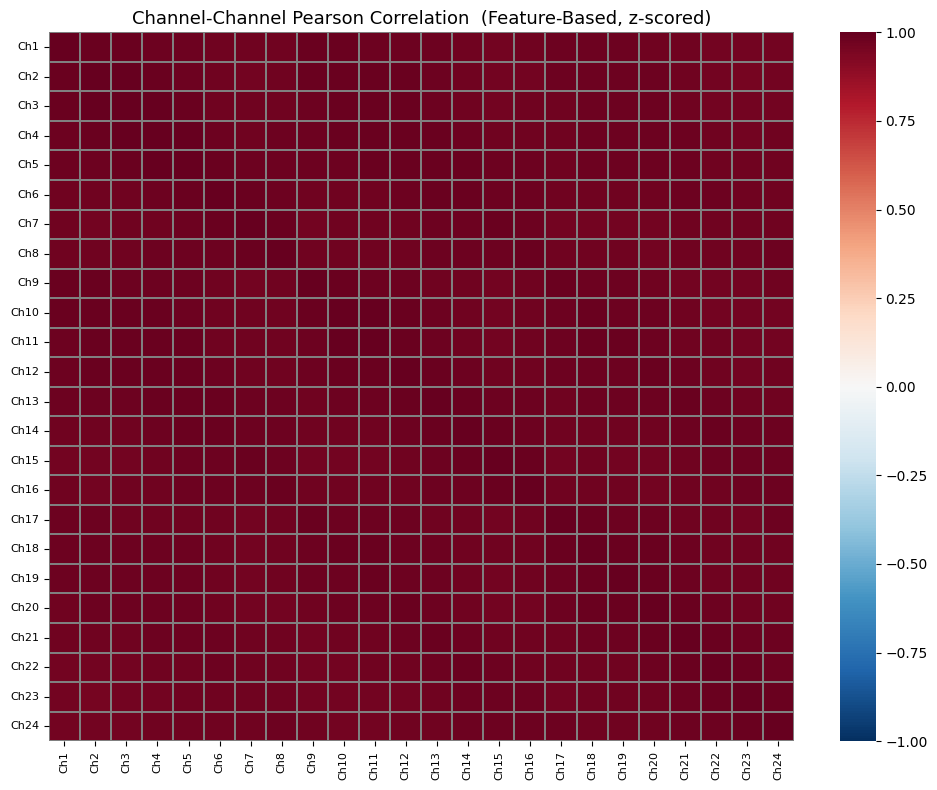

In [17]:
# (N, 24, 8) → transpose → (24, N, 8) → reshape → (24, N*8)
# Each row is one channel's complete feature stream across all windows
channel_flat = X_ch.transpose(1, 0, 2).reshape(N_CHANNELS, -1)   # (24, N*8)

# z-score each feature dimension independently (transpose, scale, transpose back)
channel_flat_z = StandardScaler().fit_transform(channel_flat.T).T  # (24, N*8)

corr_matrix = np.corrcoef(channel_flat_z)   # (24, 24)
np.fill_diagonal(corr_matrix, 1.0)

mask = ~np.eye(N_CHANNELS, dtype=bool)
print(f'Off-diagonal corr  min={corr_matrix[mask].min():.3f}  '
      f'max={corr_matrix[mask].max():.3f}  '
      f'mean={corr_matrix[mask].mean():.3f}')

ch_labels = [f'Ch{i+1}' for i in range(N_CHANNELS)]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, vmin=-1, vmax=1, cmap='RdBu_r',
            xticklabels=ch_labels, yticklabels=ch_labels,
            ax=ax, linewidths=0.3, linecolor='grey')
ax.set_title('Channel-Channel Pearson Correlation  (Feature-Based, z-scored)', fontsize=13)
ax.tick_params(axis='x', rotation=90, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig('feat_correlation_heatmap.png', dpi=150)
plt.show()

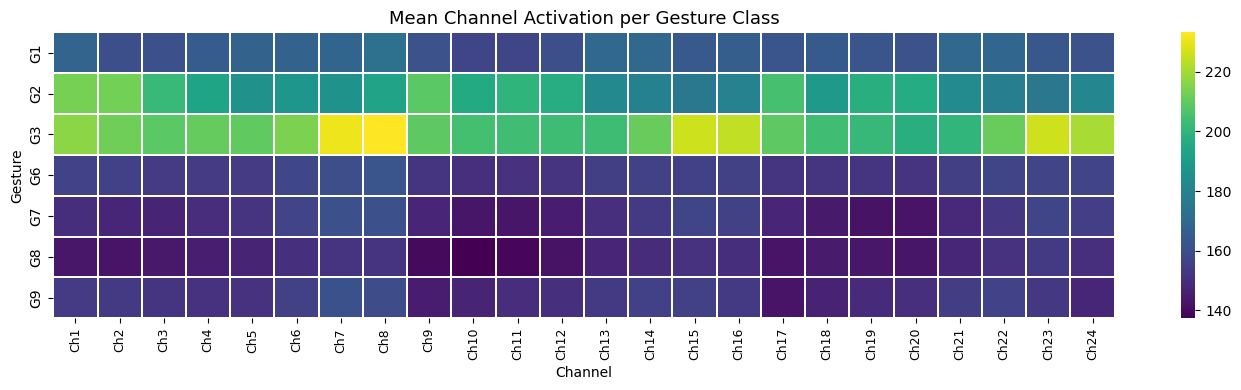

In [18]:
# Class-conditional mean activation per channel
# Channels with nearly identical rows across all 7 gestures are redundant
X_ch_scalar = X_ch.mean(axis=2)   # (N_windows, 24) — collapse 8 features to scalar

class_means = np.zeros((7, N_CHANNELS))
for g in range(7):
    class_means[g] = X_ch_scalar[y == g].mean(axis=0)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(class_means, xticklabels=ch_labels, yticklabels=GESTURE_NAMES,
            cmap='viridis', ax=ax, linewidths=0.3)
ax.set_title('Mean Channel Activation per Gesture Class', fontsize=13)
ax.set_xlabel('Channel')
ax.set_ylabel('Gesture')
ax.tick_params(axis='x', rotation=90, labelsize=9)
plt.tight_layout()
plt.savefig('feat_class_conditional.png', dpi=150)
plt.show()

---
## Agglomerative Clustering

In [19]:
# Distance = 1 - r: r=1 (identical) → dist=0, r=0 (uncorrelated) → dist=1
dist_matrix = np.clip(1.0 - corr_matrix, 0.0, None)
# Enforce exact symmetry — np.corrcoef can produce corr[i,j] != corr[j,i] by ~1e-16
dist_matrix = (dist_matrix + dist_matrix.T) / 2
np.fill_diagonal(dist_matrix, 0.0)

# squareform converts (24, 24) to condensed 1-D vector required by linkage()
condensed = squareform(dist_matrix)
Z = linkage(condensed, method='average')

# fcluster labels are 1-indexed; subtract 1 for 0-indexed channel indices
cluster_labels = fcluster(Z, N_CH_CLUSTERS, criterion='maxclust') - 1

print('Cluster composition:')
for c in range(N_CH_CLUSTERS):
    members = np.where(cluster_labels == c)[0]
    print(f'  Cluster {c}: channels {list(members + 1)}')

Cluster composition:
  Cluster 0: channels [1, 9]
  Cluster 1: channels [17]
  Cluster 2: channels [18, 19, 20]
  Cluster 3: channels [2, 3, 4, 5, 10, 11, 12]
  Cluster 4: channels [15, 16]
  Cluster 5: channels [6, 7, 8]
  Cluster 6: channels [23, 24]
  Cluster 7: channels [13, 14, 21, 22]


In [20]:
# Medoid = channel with highest mean Pearson r to all other cluster members
# More robust than centroid: stays in the original channel space
representative_channels = []

for c in range(N_CH_CLUSTERS):
    members  = np.where(cluster_labels == c)[0]
    sub_corr = corr_matrix[np.ix_(members, members)]
    avg_corr = sub_corr.mean(axis=1)
    rep      = members[np.argmax(avg_corr)]
    representative_channels.append(rep)
    print(f'  Cluster {c}: {list(members + 1)}  ->  Ch{rep + 1} (idx {rep})')

representative_channels = sorted(representative_channels)
print(f'\nFinal representatives (0-indexed): {representative_channels}')
print(f'Final representatives (1-indexed): {[c + 1 for c in representative_channels]}')

  Cluster 0: [1, 9]  ->  Ch1 (idx 0)
  Cluster 1: [17]  ->  Ch17 (idx 16)
  Cluster 2: [18, 19, 20]  ->  Ch19 (idx 18)
  Cluster 3: [2, 3, 4, 5, 10, 11, 12]  ->  Ch4 (idx 3)
  Cluster 4: [15, 16]  ->  Ch15 (idx 14)
  Cluster 5: [6, 7, 8]  ->  Ch7 (idx 6)
  Cluster 6: [23, 24]  ->  Ch23 (idx 22)
  Cluster 7: [13, 14, 21, 22]  ->  Ch21 (idx 20)

Final representatives (0-indexed): [0, 3, 6, 14, 16, 18, 20, 22]
Final representatives (1-indexed): [1, 4, 7, 15, 17, 19, 21, 23]


In [21]:
def plot_dendrogram_with_cut(Z, k, n_channels=24, title='Channel Dendrogram',
                              save_path=None, representative_channels=None):
    """Draw dendrogram with a dashed cut line at height that yields exactly k clusters.

    Z[-(k-1), 2] is the merge distance at which the tree transitions from k+1 to k
    clusters, so cutting there gives exactly k groups.
    """
    cut_height = Z[-(k - 1), 2]
    ch_labels  = [f'Ch{i+1}' for i in range(n_channels)]

    fig, ax = plt.subplots(figsize=(14, 5))
    dendrogram(Z, labels=ch_labels, color_threshold=cut_height,
               ax=ax, leaf_rotation=0, leaf_font_size=10)
    ax.axhline(cut_height, color='red', linestyle='--', linewidth=1.5,
               label=f'k={k} cut  (dist={cut_height:.4f})')
    ax.legend(fontsize=10)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Channel')
    ax.set_ylabel('Correlation distance  (1 - r)')

    if representative_channels:
        ylim   = ax.get_ylim()
        offset = (ylim[1] - ylim[0]) * 0.07
        for tick in ax.get_xticklabels():
            ch_idx = int(tick.get_text().replace('Ch', '')) - 1
            if ch_idx in representative_channels:
                ax.text(tick.get_position()[0], ylim[0] - offset, chr(9733),
                        ha='center', va='top', fontsize=13, color='red',
                        transform=ax.transData)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Cut height : {cut_height:.4f}  |  Clusters: {k}')

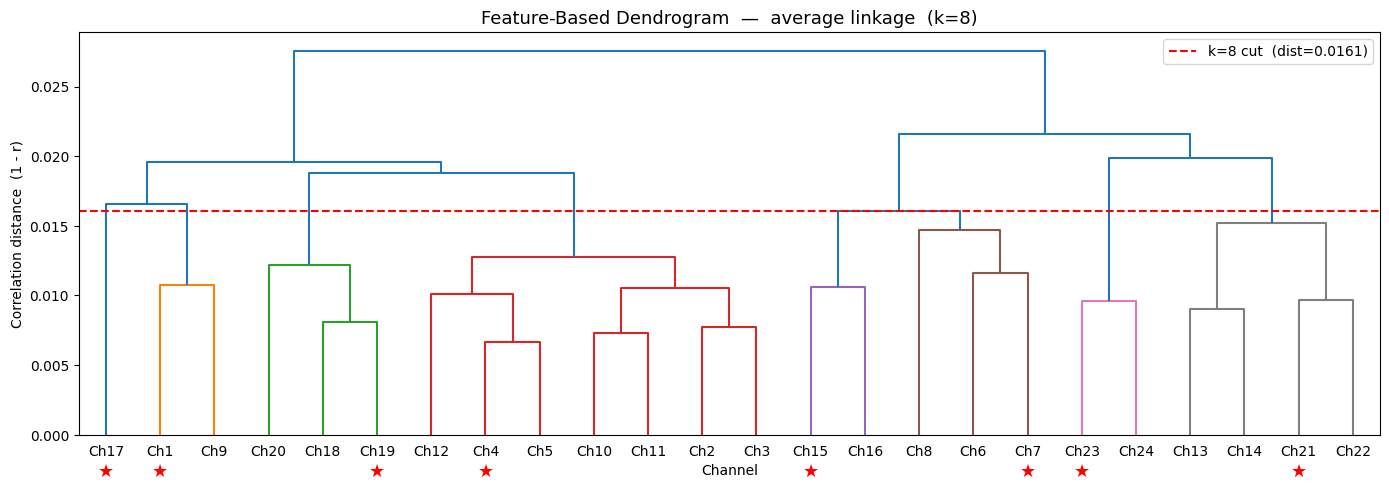

Cut height : 0.0161  |  Clusters: 8


In [22]:
plot_dendrogram_with_cut(
    Z, k=N_CH_CLUSTERS,
    title=f'Feature-Based Dendrogram  —  average linkage  (k={N_CH_CLUSTERS})',
    save_path='feat_dendrogram.png',
    representative_channels=representative_channels,
)

  k= 2  silhouette=0.3435
  k= 3  silhouette=0.3006
  k= 4  silhouette=0.2866
  k= 5  silhouette=0.2369
  k= 6  silhouette=0.2742
  k= 7  silhouette=0.2525
  k= 8  silhouette=0.2396
  k= 9  silhouette=0.2414
  k=10  silhouette=0.2294
  k=11  silhouette=0.2164
  k=12  silhouette=0.1935


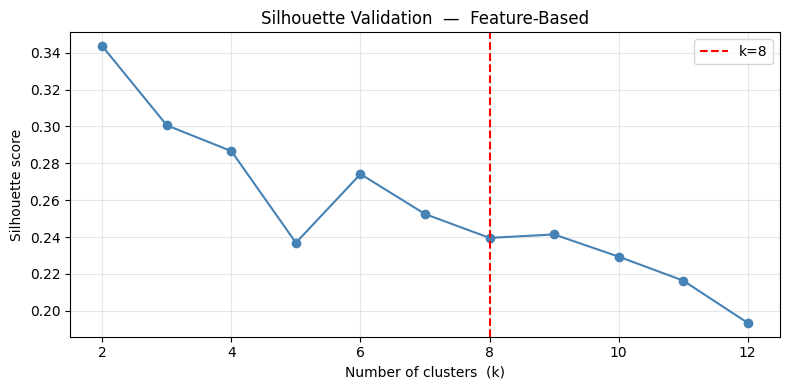

In [23]:
# Silhouette score: +1 = well-separated, 0 = overlapping, -1 = wrong cluster
# Sweep k=2..12 to check whether k=8 sits near a local maximum
k_range    = range(2, 13)
sil_scores = []

for k in k_range:
    labels_k = fcluster(Z, k, criterion='maxclust') - 1
    score    = silhouette_score(dist_matrix, labels_k, metric='precomputed')
    sil_scores.append(score)
    print(f'  k={k:>2}  silhouette={score:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), sil_scores, marker='o', color='steelblue', linewidth=1.5)
ax.axvline(N_CH_CLUSTERS, color='red', linestyle='--', label=f'k={N_CH_CLUSTERS}')
ax.set_xlabel('Number of clusters  (k)')
ax.set_ylabel('Silhouette score')
ax.set_title('Silhouette Validation  —  Feature-Based')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('feat_silhouette.png', dpi=150)
plt.show()

In [24]:
np.save('feat_representative_channels.npy', np.array(representative_channels))
np.save('feat_cluster_labels.npy', cluster_labels)
print('Saved:  feat_representative_channels.npy   feat_cluster_labels.npy')
print(f'Selected channels (1-indexed): {[c + 1 for c in representative_channels]}')
print()
print('To use in the efficient model notebook:')
print('  channels = np.load("experiments/clustering/feat_representative_channels.npy")')
print('  X_reduced = X[:, :, channels, :]   # (N, 1, 8, 1500)  [for DL]')
print('  # or select corresponding feature columns for feature-based models')

Saved:  feat_representative_channels.npy   feat_cluster_labels.npy
Selected channels (1-indexed): [1, 4, 7, 15, 17, 19, 21, 23]

To use in the efficient model notebook:
  channels = np.load("experiments/clustering/feat_representative_channels.npy")
  X_reduced = X[:, :, channels, :]   # (N, 1, 8, 1500)  [for DL]
  # or select corresponding feature columns for feature-based models
